
## Bagging vs Random Forest for Subsurface Production Prediction

#### Chingiz Asgarli
#### Petroleum and Geosystems Engineering, The University of Texas at Austin


### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)


### Executive Summary

We will look at how well Bagging and Random Forest ensemble methods work for predicting the production of unconventional wells in this project.  The workflow begins with a decision tree that has a lot of variance. It then gradually adds ensemble averaging and random feature selection to see how they affect the bias-variance trade-off.  Bagging makes generalization much better than the single tree, and the untuned Random Forest makes variance even lower, getting a higher testing R² and a lower testing RMSE than Bagging, but its testing MAE is a little higher.  After tuning the hyperparameters, the Random Forest model is the best overall. It beats Bagging on all evaluation metrics, including MAE, RMSE, and R².  The tuned Random Forest finds the best balance between bias and variance, showing how important it is to choose the right parameters and regularize the model.  In general, the tuned Random Forest makes the most stable and accurate predictions for this two-feature subsurface workflow.

### Packages Imported

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 13
np.random.seed(RANDOM_STATE)

I imported the core Python libraries required for data handling, visualization, and machine learning. I use scikit-learn for model implementation. It includes decision trees, bagging, and random forest, and some standard regression metrics such as MAE, RMSE, and R².

### Functions

In [83]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Fit the model, generate predictions, and return key regression metrics.
    """
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    results = {
        "model": model_name,
        "MAE_train": mae_train,
        "MAE_test": mae_test,
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "R2_train": r2_train,
        "R2_test": r2_test
    }

    return results, y_train_pred, y_test_pred
    

def plot_predicted_vs_actual(y_train, y_train_pred, y_test, y_test_pred, title):
    """
    Predicted vs actual production for train and test sets.
    """
    plt.figure(figsize=(6, 6))
    plt.scatter(y_train, y_train_pred, alpha=0.7, label="Train")
    plt.scatter(y_test, y_test_pred, alpha=0.7, label="Test")
    max_val = max(y_train.max(), y_test.max())
    min_val = min(y_train.min(), y_test.min())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual Production")
    plt.ylabel("Predicted Production")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_learning_curve_model(estimator, X, y, title, cv=5):
    """
    Plot learning curve (train and validation scores vs. number of training samples).
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring="r2", n_jobs=-1, random_state=RANDOM_STATE
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(6, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training R²")
    plt.plot(train_sizes, val_mean, marker="s", label="Validation R²")
    plt.xlabel("Number of Training Samples")
    plt.ylabel("R² Score")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

Here I defined functions to evaluate models, generate predicted vs actual plots, and construct learning curves. These tools will help me quantify and visualize overfitting and generalization behavior for the bagging and random forest workflows.

### Loaded Data

The following workflow applies the .csv file 'unconv_MV_v5.csv', a synthetic dataset created by Michael Pyrcz for geostatistical modeling. The dataset is publically available [here](https://github.com/GeostatsGuy/GeoDataSets/blob/master/unconv_MV_v5.csv)  

In [91]:
data = pd.read_csv("unconv_MV_v5.csv")
data.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


I load the subsurface dataset containing well-based petrophysical features and production response. The key predictor features are porosity (Por), permeability (Perm), acoustic impedance (AI), brittleness, TOC, and vitrinite reflectance (VR), while the response variable is production (Prod). Each row corresponds to a well observation.

In [89]:
data.describe()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,14.991150,4.330750,2.968850,48.161950,0.990450,1.964300,4311.219852
std,57.879185,2.971176,1.731014,0.566885,14.129455,0.481588,0.300827,992.038414
min,1.000000,6.550000,1.130000,1.280000,10.940000,-0.190000,0.930000,2107.139414
25%,50.750000,12.912500,3.122500,2.547500,37.755000,0.617500,1.770000,3618.064513
50%,100.500000,15.070000,4.035000,2.955000,49.510000,1.030000,1.960000,4284.687348
75%,150.250000,17.402500,5.287500,3.345000,58.262500,1.350000,2.142500,5086.089761
max,200.000000,23.550000,9.870000,4.630000,84.330000,2.180000,2.870000,6662.622385


It is always useful to visualize the summary statistics that provide a first check of the range and variability of the predictors and production response. This also serves as a basic data quality check before selecting features and splitting into training and testing subsets.

### Bagging vs Random Forest Workflow for Production Prediction

The purpose of this workflow is to compare the Bagging and Random Forest ensemble methods for predicting the production of unconventional wells and to figure out how random feature selection affects the bias–variance trade-off.  I concentrate on two primary petrophysical predictors—porosity (Por) and acoustic impedance (AI)—to facilitate interpretation and visualization.  These characteristics are physically connected to the quality of the reservoir and the seismic response. They also provide a small, low-dimensional environment for studying ensemble behavior.

#### Feature Selection and Train–Test Split

Here I select the petrophysical features to use as predictors and split the data into training and testing sets. The train–test split allows me to evaluate how well each model generalizes to unseen wells.

In [90]:
# select features and response
feature_cols = ["Por", "AI"]
X = data[feature_cols]
y = data["Prod"]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape


((160, 2), (40, 2))

The feature matrix **X** contains only porosity and acuostic impedance, while **y** contains production. The shapes above confirm the number of wells allocated to the training and testing subsets, which will be held constant for all subsequent models. This is done to ensure a consistent comparison.

#### Baseline Decision Tree Model

Before introducing ensemble methods, I first fit a single decision tree regressor. This baseline shows how an individual tree performs on this dataset and provides a reference point to understand the benefits of bagging and random forest for variance reduction.


In [93]:
# baseline decision tree regressor
tree_model = DecisionTreeRegressor(random_state=RANDOM_STATE)

tree_results, y_train_pred_tree, y_test_pred_tree = evaluate_regression_model(
    tree_model,
    X_train, X_test,
    y_train, y_test,
    model_name="Decision Tree"
)

tree_results

{'model': 'Decision Tree',
 'MAE_train': 0.0,
 'MAE_test': 592.5124736,
 'RMSE_train': np.float64(0.0),
 'RMSE_test': np.float64(802.2647639072715),
 'R2_train': 1.0,
 'R2_test': 0.2646830079840661}

The table above summarizes the baseline decision tree performance. The training metrics show how closely the tree fits the wells it was trained on, while the testing metrics indicate how well it generalizes to unseen wells. A large gap between training and testing performance (for example, very high training R² but much lower testing R², or much lower training error than testing error) is a sign of overfitting. And, that's why it's in our interest to use ensemble methods, which are deisgned to mitigate that.

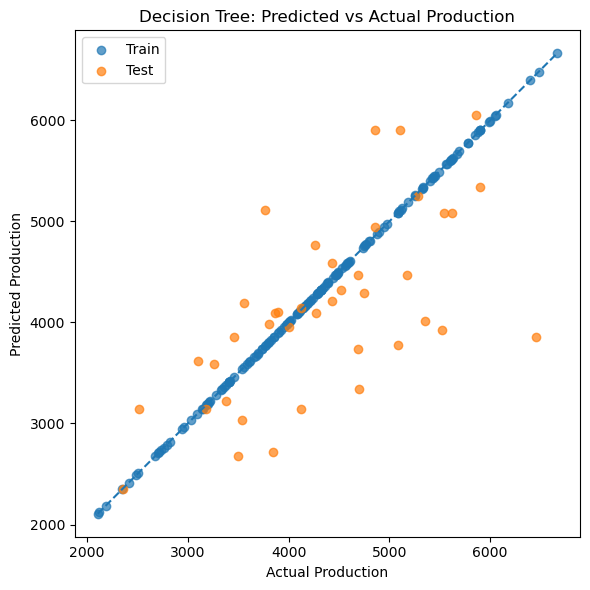

In [94]:
plot_predicted_vs_actual(
    y_train, y_train_pred_tree,
    y_test, y_test_pred_tree,
    title="Decision Tree: Predicted vs Actual Production"
)

This plot compares predicted versus actual production for both the training and testing wells. Points close to the 1:1 line indicate accurate predictions, while large deviations indicate error. If the training points gather tightly around the line but the testing points are more scattered, this visually confirms overfitting of the single decision tree model.

#### Bagging Workflow

Next, I implement a BaggingRegressor with decision trees as base learners. Bagging reduces variance by training many trees on bootstrap resamples of the training data and averaging their predictions. This ensemble should be more stable and less overfit than a single decision tree while still preserving a flexible model structure.

In [85]:
# Bagging regressor with decision trees
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    n_estimators=200,
    random_state=RANDOM_STATE
)

bagging_results, y_train_pred_bag, y_test_pred_bag = evaluate_regression_model(
    bagging_model,
    X_train, X_test,
    y_train, y_test,
    model_name="Bagging (Decision Trees)"
)

bagging_results

{'model': 'Bagging (Decision Trees)',
 'MAE_train': 181.12013216996837,
 'MAE_test': 399.3476594006254,
 'RMSE_train': np.float64(233.89012017249527),
 'RMSE_test': np.float64(519.3381512042002),
 'R2_train': 0.945527755120307,
 'R2_test': 0.6918660005535007}

The summary above reports the bagging model performance on both the training and testing wells. Compared to the single decision tree, I expect the bagging ensemble to reduce variance, which should appear as more stable testing metrics (for example, improved testing R² and lower testing RMSE and MAE). The gap between training and testing performance indicates the remaining level of overfitting.

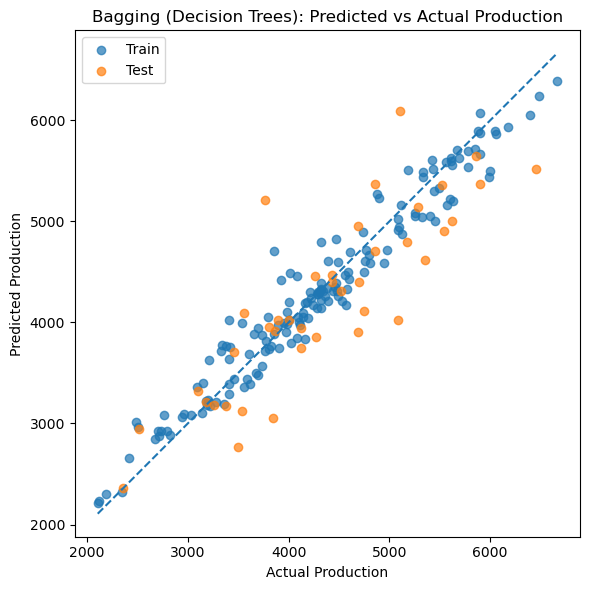

In [95]:
plot_predicted_vs_actual(
    y_train, y_train_pred_bag,
    y_test, y_test_pred_bag,
    title="Bagging (Decision Trees): Predicted vs Actual Production"
)

The predicted versus actual plot for the bagging workflow shows how well the ensemble reflects the production response. If the testing points are closer to the 1:1 line than for the single decision tree, this means that the model is better at generalizing. Any remaining systematic deviations or spread in the testing points show that the model is not very accurate and could be biased or have variance in the workflow.

#### Random Forest Workflow

I now implement a RandomForestRegressor. Random Forest extends bagging by introducing random feature selection at each split and random split thresholds. This selection decorrelates individual trees and can further reduce variance. Even with only two predictors, this additional randomness may lead to better generalization than bagging alone.

In [97]:
# Random forest regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",       # random subset of features at each split
    random_state=RANDOM_STATE
)

rf_results, y_train_pred_rf, y_test_pred_rf = evaluate_regression_model(
    rf_model,
    X_train, X_test,
    y_train, y_test,
    model_name="Random Forest"
)

rf_results

{'model': 'Random Forest',
 'MAE_train': 182.35018952612478,
 'MAE_test': 404.49002951824974,
 'RMSE_train': np.float64(233.65290513696405),
 'RMSE_test': np.float64(506.3039451278012),
 'R2_train': 0.945638192301939,
 'R2_test': 0.7071388329754942}

The random forest performance metrics can be directly compared to the bagging results. I am particularly interested in the testing R² and RMSE values, since improvements in these metrics indicate that random feature selection and additional randomness have successfully reduced variance and improved generalization, even though training error may be slightly higher.

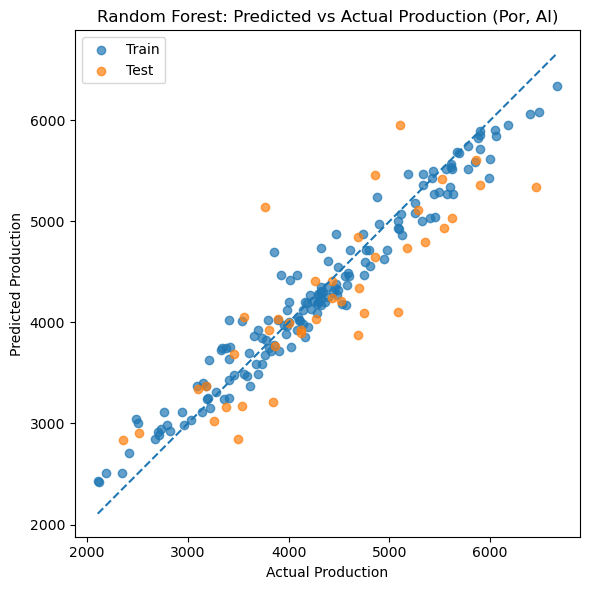

In [98]:
plot_predicted_vs_actual(
    y_train, y_train_pred_rf,
    y_test, y_test_pred_rf,
    title="Random Forest: Predicted vs Actual Production (Por, AI)"
)

The predicted versus actual plot for the random forest model shows how well the ensemble captures production for the training and testing wells. If the testing points are slightly closer to the 1:1 line than for bagging, this supports the conclusion that random forest generalizes better for this two-feature workflow.

#### Feature Importance

One advantage of tree-based ensemble methods is that they provide a natural measure of feature importance based on how often and how effectively each feature is used to split the data. For this workflow, feature importance helps quantify the relative contribution of porosity (Por) and acoustic impedance (AI) to production prediction. This provides a useful link between the machine learning model and subsurface interpretation.

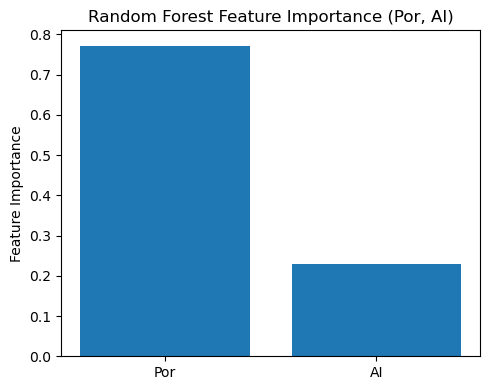

(array([0.77164561, 0.22835439]), ['Por', 'AI'])

In [100]:
# Feature importance from the random forest model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(5, 4))
plt.bar(range(len(feature_cols)), importances[indices])
plt.xticks(range(len(feature_cols)), np.array(feature_cols)[indices], rotation=0)
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance (Por, AI)")
plt.tight_layout()
plt.show()

importances, feature_cols


#### Hyperparameter Tuning for Random Forest

To further explore the bias–variance trade-off, I tune key Random Forest hyperparameters using cross-validation on the training data. I focus on the number of trees, the number of features considered at each split, the maximum tree depth, and the minimum number of samples per leaf. This helps identify a configuration that provides the best generalization performance for the Porosity and AI predictors.

In [103]:
param_grid = {
    "n_estimators": [100, 200],
    "max_features": [1, 2],        # 1 vs both features per split
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

rf_base = RandomForestRegressor(random_state=RANDOM_STATE)

rf_tuning = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_tuning.fit(X_train, y_train)
rf_tuning.best_params_

{'max_depth': 5, 'max_features': 2, 'min_samples_leaf': 5, 'n_estimators': 200}

The best parameter combination reported above shows a balance between model flexibility and regularization. Larger maximum depth and smaller leaf sizes generally reduce bias but increase variance, while limiting depth or increasing the minimum samples per leaf. Changing `max_features` between 1 and 2 controls how strongly trees are decorrelated. This is important, because it directly influences the variance reduction effect.

In [104]:
best_rf = rf_tuning.best_estimator_

best_rf_results, y_train_pred_best_rf, y_test_pred_best_rf = evaluate_regression_model(
    best_rf,
    X_train, X_test,
    y_train, y_test,
    model_name="Tuned Random Forest (Por, AI)"
)

best_rf_results

{'model': 'Tuned Random Forest (Por, AI)',
 'MAE_train': 354.8297327232639,
 'MAE_test': 395.8886611843698,
 'RMSE_train': np.float64(445.4771755809716),
 'RMSE_test': np.float64(469.12513825010393),
 'R2_train': 0.8023929501549217,
 'R2_test': 0.7485703003261521}

The tuned Random Forest achieves the best performane among all models. We can read the lowest testing MAE and RMSE and the highest testing R². The lower training R² (0.80) shows that the tuning successfully increased bias to reduce variance. This goes to show how appropriate regularization is usually necessary for unlocking the ensemble performance to its full potential.

### Model Comparison

To summarize the results, I compile the key performance metrics for all models—decision tree, bagging, random forest, and tuned random forest—into a single table. This comparison shows the progression from a high-variance single tree to more stable ensemble methods and the additional benefits of hyperparameter tuning.

In [106]:
import pandas as pd

results_list = [
    tree_results,
    bagging_results,
    rf_results,
    best_rf_results
]

results_df = pd.DataFrame(results_list)
results_df

,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Decision Tree,0.000000,592.512474,0.000000,802.264764,1.000000,0.264683
1,Bagging (Decision Trees),181.120132,399.347659,233.890120,519.338151,0.945528,0.691866
2,Random Forest,182.350190,404.490030,233.652905,506.303945,0.945638,0.707139
3,"Tuned Random Forest (Por, AI)",354.829733,395.888661,445.477176,469.125138,0.802393,0.748570


The comparison table clearly illustrates the progression from a highly overfit decision tree to more stable ensemble methods. Bagging greatly improves generalization, Random Forest improves it further for R² and RMSE, and the tuned Random Forest delivers the best results across all metrics. The tuned model reduces both error and variance by controlling depth and leaf size, and it outperforms Bagging and the untuned Random Forest in MAE, RMSE, and R². This demonstrates that the best ensemble performance comes from balancing bias and variance rather than prioritizing training accuracy.

#### Conclusions and Recommendations

This workflow demonstrates how ensemble learning methods manage the bias–variance trade-off in subsurface production prediction using porosity and acoustic impedance as predictors. The single decision tree noticeably overfits and provides poor generalization. Bagging greatly reduces variance and achieves strong testing performance. The untuned Random Forest improves generalization further, but still shows a slightly higher testing MAE than Bagging.

Hyperparameter tuning of the Random Forest produces the best overall model. The tuned Random Forest achieves the lowest testing MAE and RMSE and the highest testing R², and it intentionally reduces training R² through regularization too. This demonstrates that ensemble performance improves not only through averaging but also through careful tuning of model complexity. 

For this two-feature workflow, a tuned Random Forest is recommended as the most stable and accurate model. It provides the optimal balance between bias and variance for predicting unconventional well production.


#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)